In [28]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_bvp

In [29]:
rho_mem = 1980  # kg.m-3. It is the density of the dry membrane.
M_eq = 2.1  # kg.mol-1. It is the equivalent molar mass of ionomer.
F = 96485.3329  # C.mol-1. It is the Faraday constant.
R = 8.314  # J/(mol.K). It is the ideal gas constant.
M_H2O = 18.01528e-3  # kg/mol. It
yO2_ext = 0.21  # molar fraction of oxygen in the external gas phase.
epsilon_gdl = 0.5 
epsilon_c = 0.3
epsilon_cl = 0.4
gamma_cond = 5e3  # s-1. It is the overall condensation rate constant for water.
gamma_evap = 1e-4  # Pa-1.s-1. It is the overall evaporation rate constant for water.
theta_c_gdl = 120 * np.pi / 180  # radian. It is the contact angle of GDL for liquid water.
Psat = lambda T: 101325 * 10 ** (-2.1794 + 0.02953 * (T - 273.15) - 9.1837e-5 * (T - 273.15) ** 2 + 1.4454e-7 * (T - 273.15) ** 3)

def rho_H2O(T):
    return ((999.83952 + 16.945176 * (T - 273.15) - 7.9870401e-3 * (T - 273.15) ** 2 - 46.170461e-6 * (T - 273.15) ** 3
                 + 105.56302e-9 * (T - 273.15) ** 4 - 280.54253e-12 * (T - 273.15) ** 5) /
                (1 + 16.879850e-3 * (T - 273.15)))
def sigma(T):
    return 235.8e-3 * ((647.15 - T) / 647.15) ** 1.256 * (1 - 0.625 * (647.15 - T) / 647.15)
def K0(epsilon, epsilon_c, epsilon_gdl):
    if epsilon_gdl < 0.67:
        beta1 = -3.60
    else:
        beta1 = -2.60
    return epsilon / (8 * np.log(epsilon) ** 2) * (epsilon - 0.11) ** (0.785 + 2) * 4.6e-6 ** 2 / ((1 - 0.11) ** 0.785 * ((0.785 + 1) * epsilon - 0.11) ** 2) * np.exp(beta1 * epsilon_c)
def nu_l(T):
    mu_l = 2.414 * 10 ** (-5 + 247.8 / (T - 140.0))  # Pa.s. It is the liquid water dynamic viscosity.
    return mu_l / rho_H2O(T)

def Svl(s, C_v, Ctot, epsilon, T):
    C_v_sat = Psat(T)/(R * T)
    if C_v >= C_v_sat:  # condensation
            return gamma_cond * epsilon * (1 - s) * (C_v / Ctot) * (C_v - C_v_sat)
    else:  # evaporation
            return -gamma_evap * epsilon * s * rho_H2O(T) / M_H2O * R * T * (C_v_sat - C_v)
    
def Dw(lambdaa, T):
    lambdaa = np.asarray(lambdaa)
    Dw_low = 3.1 * 1e-7 * lambdaa * (np.exp(0.28 * lambdaa) - 1) * np.exp(-2436 / T)
    Dw_high = 4.17 * 1e-8 * lambdaa * (161 * np.exp(-lambdaa) + 1) * np.exp(-2436 / T)
    return np.where(lambdaa < 3, Dw_low, Dw_high)

def Ds_gdl(s_gdl, T_gdl):
    Ds = - sigma(T_gdl) * K0_gdl / nu_l(T_gdl) * abs(np.cos(theta_c_gdl)) * (epsilon_gdl / K0_gdl) ** 0.5 * \
            (s_gdl ** 3 + 1e-7) * (1.417 - 4.24 * s_gdl + 3.789 * s_gdl ** 2)
    return Ds

def Deff(s, P, T):
    if  0.67 <= epsilon_gdl < 0.8:
        beta2 = -0.90
    else:
        beta2 = -1.59
    Dc = 3.242e-5 * (T / 298.15) ** 2.334 * (101325 / P)
    epsilon = (epsilon_gdl + epsilon_cl) / 2
    return epsilon * ((epsilon - 0.11) / (1 - 0.11)) ** 0.785 * np.exp(beta2 * epsilon_c) * (1 - s) ** 2 * Dc

def lambda_eq(C_v, s, T, Kshape):
    C_v_sat = Psat(T)/(R * T)
    a_w = C_v / C_v_sat + 2 * s  # water activity
    return 0.5 * (0.3 + 10.8 * a_w - 16.0 * a_w ** 2 + 14.1 * a_w ** 3) * (1 - np.tanh(100 * (a_w - 1))) \
               + 0.5 * (9.2 + 8.6 * (1 - np.exp(-Kshape * (a_w - 1)))) * (1 + np.tanh(100 * (a_w - 1)))

K0_gdl = K0(epsilon_gdl, epsilon_c, epsilon_gdl)

In [30]:
# Operation conditions
Sc = 2.5
Sa = 1.2
Tdes = 60 + 273.15
Pa_des = 1.3e5
Pc_des = 1.3e5
Phi_a_des = 0.1
Phi_c_des = 0.5
iload = 1.2e4 # A/m2

#### Boundary conditions

In [31]:
lambda_ccl = 22
iload = 0.5e4
Pc_des = 1.5e5
s_cgc = 0.05
s_agc = 0.0
C_v_cbd = Phi_c_des * Psat(Tdes) / (R * Tdes) 
C_O2_cbd = yO2_ext * (Pc_des - Phi_c_des * Psat(Tdes)) / (R * Tdes)
C_N2 = (1- yO2_ext) * (Pc_des - Phi_c_des * Psat(Tdes)) / (R * Tdes)
C_v_abd = Phi_a_des * Psat(Tdes) / (R * Tdes)
C_H2_abd =  (Pa_des - Phi_a_des * Psat(Tdes)) / (R * Tdes)
Csat = Psat(Tdes) / (R * Tdes)

In [32]:
def F_GDL(x, y):
    
    n_points = x.size
    dydx = np.zeros_like(y)
    # Extract state variables from y
    s_cgdl = y[0,:]
    Js_cgdl = y[1,:]
    s_agdl = y[2,:]
    Js_agdl = y[3,:]
    Cv_cgdl = y[4,:]
    Jv_cgdl = y[5,:]
    Cv_agdl = y[6,:]
    Jv_agdl = y[7,:]
    # Calculate derivatives 
    ds_cgdl = np.zeros_like(x)
    ds_agdl = np.zeros_like(x)
    dCv_cgdl = np.zeros_like(x)
    dCv_agdl = np.zeros_like(x)
    # Calculate derivatives for fluxes
    dJs_cgdl = np.zeros_like(x)
    dJs_agdl = np.zeros_like(x)
    dJv_cgdl = np.zeros_like(x)
    dJv_agdl = np.zeros_like(x)

    for i_node in range(n_points):
        if C_v_abd < Csat:
            dJs_agdl[i_node] = 0
            dJv_agdl[i_node] = 0
        else:
            dJs_agdl[i_node] = Svl(s_agdl[i_node], Psat(333.15)/(R * 333.15), Pa_des, epsilon_gdl, 333.15)
            dJv_agdl[i_node] = -Svl(s_agdl[i_node], Cv_agdl[i_node], Pa_des/(R * 333.15), epsilon_gdl, 333.15)

        if C_v_cbd < Csat:
            dJs_cgdl[i_node] = 0
            dJv_cgdl[i_node] = 0
        else:
            dJs_cgdl[i_node] = Svl(s_cgdl[i_node], Psat(333.15)/(R * 333.15), Pc_des, epsilon_gdl, 333.15)
            dJv_cgdl[i_node] = -Svl(s_cgdl[i_node], Cv_cgdl[i_node], Pc_des/(R * 333.15), epsilon_gdl, 333.15)

        ds_cgdl[i_node] = -Js_cgdl[i_node] / (rho_H2O(333.15) * 0.6) / Ds_gdl(s_cgdl[i_node], 333.15)
        ds_agdl[i_node] = -Js_agdl[i_node] / (rho_H2O(333.15) * 0.6) / Ds_gdl(s_agdl[i_node], 333.15)
        dCv_cgdl[i_node] = -Jv_cgdl[i_node] / (epsilon_gdl*(1-s_cgdl[i_node])) / Deff(s_cgdl[i_node], 333.15, Pc_des) 
        dCv_agdl[i_node] =-Jv_agdl[i_node] / (epsilon_gdl * (1 - s_agdl[i_node])) / Deff(s_agdl[i_node], 333.15, Pa_des) 

    dydx[0,:] = ds_cgdl
    dydx[1,:] = dJs_cgdl
    dydx[2,:] = ds_agdl
    dydx[3,:] = dJs_agdl
    dydx[4,:] = dCv_cgdl
    dydx[5,:] = dJv_cgdl
    dydx[6,:] = dCv_agdl
    dydx[7,:] = dJv_agdl
    return dydx

def bc_GDL(ya, yb):
        return np.array([ya[0] - 0.1, yb[0] - s_cgc,
                                      ya[2] - s_agc, yb[2] - 0,
                                      ya[4] - (C_v_cbd+ 2), yb[4] - C_v_cbd,
                                      ya[6] - C_v_abd, yb[6] - (C_v_abd+1)])

x_mesh = np.linspace(0, 2e-4, 10)
y_init = np.zeros((8, x_mesh.size))
s_init = [s_cgc + i * 0.01 for i in range(10)][::-1]
js_init = [0 for i in range(10)]
y_init[0, :] = s_init
y_init[1, :] = js_init
sol = solve_bvp(F_GDL, bc_GDL, x_mesh, y_init, tol=1e-6, max_nodes=5000)
if not sol.success:
    print("BVP solver did not converge:", sol.message)
print("Success:", sol.success)

Success: True


Text(0, 0.5, '$C_{v,cgdl}$ (mol/m3)')

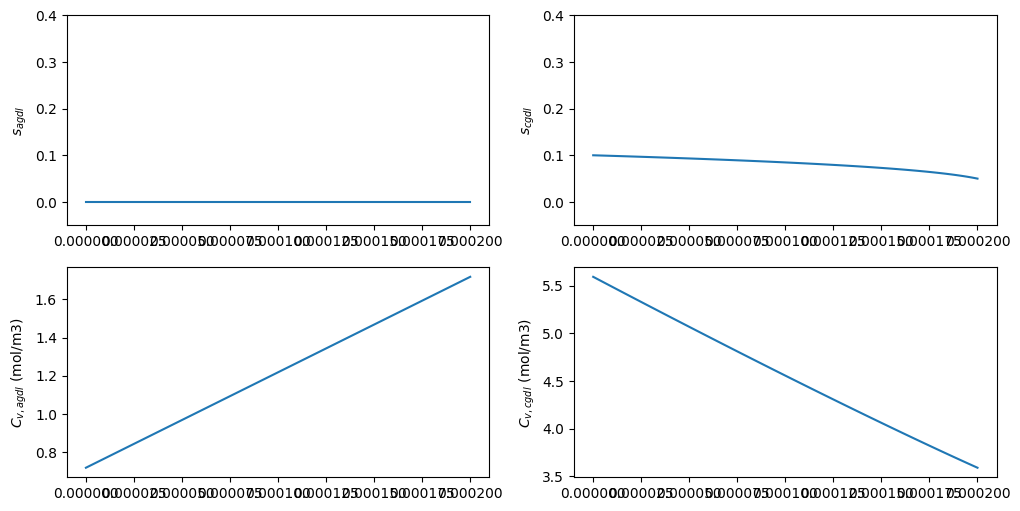

In [33]:
fig, axes = plt.subplots(ncols=2, nrows=2, figsize=(12, 6))
axes[0,0].plot(sol.x, sol.y[2, :])
axes[0,0].set_ylim(-0.05, 0.4)
axes[0,0].set_ylabel(r'$s_{agdl}$')
axes[0,1].plot(sol.x, sol.y[0, :])
axes[0,1].set_ylim(-0.05, 0.4)
axes[0,1].set_ylabel(r'$s_{cgdl}$')
axes[1,0].plot(sol.x, sol.y[6, :])
axes[1,0].set_ylabel(r'$C_{v,agdl}$ (mol/m3)')
axes[1,1].plot(sol.x, sol.y[4, :])
axes[1,1].set_ylabel(r'$C_{v,cgdl}$ (mol/m3)')


Text(0, 0.5, '$Jv_{cgdl}$ (mol/m3)')

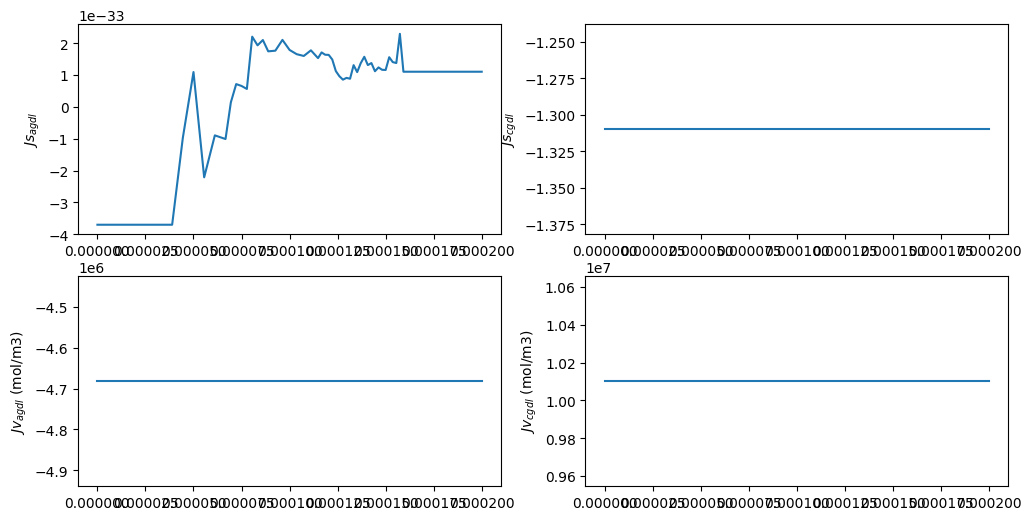

In [34]:
fig, axes = plt.subplots(ncols=2, nrows=2, figsize=(12, 6))
axes[0,0].plot(sol.x, sol.y[3, :])
axes[0,0].set_ylabel(r'$Js_{agdl}$')
axes[0,1].plot(sol.x, sol.y[1, :])
axes[0,1].set_ylabel(r'$Js_{cgdl}$')
axes[1,0].plot(sol.x, sol.y[7, :])
axes[1,0].set_ylabel(r'$Jv_{agdl}$ (mol/m3)')
axes[1,1].plot(sol.x, sol.y[5, :])
axes[1,1].set_ylabel(r'$Jv_{cgdl}$ (mol/m3)')

In [35]:
def gamma_sorp(C_v, s, lambdaa, T, Hcl, Kshape):
    fv = (lambdaa * M_H2O / rho_H2O(T)) / (M_eq / rho_mem + lambdaa * M_H2O / rho_H2O(T))  # water volume fraction of the membrane
    if lambda_eq(C_v, s, T, Kshape) >= lambdaa:  # type_flow = absorption
        return (1.14e-5 * fv) / Hcl * np.exp(2416 * (1 / 303 - 1 / T))
    else:  # type_flow = desorption
        return (4.59e-5 * fv) / Hcl * np.exp(2416 * (1 / 303 - 1 / T))

In [59]:
lambda_eq_acl = lambda_eq(C_v_abd+1, 0, 333.15, 20)
lambda_eq_ccl = lambda_eq(C_v_cbd+2, 0.1, 333.15, 20)
lambda_acl = lambda_eq_acl - gamma_sorp(C_v_abd+1, 0, lambda_eq_acl, 333.15, 0.1, 20) 
lambda_ccl = lambda_eq_ccl - gamma_sorp(C_v_cbd+2, 0.1, lambda_eq_ccl, 333.15, 0.1, 20)

In [60]:
Klambda = rho_mem/M_eq * Dw(lambda_acl, 333.15) / (2.5/22 * iload / F)
lambda_mem = [lambda_acl * np.exp(x/Klambda) for x in np.linspace(0, 2e-5, 10)]
lambda_ccl = lambda_mem[-1] 

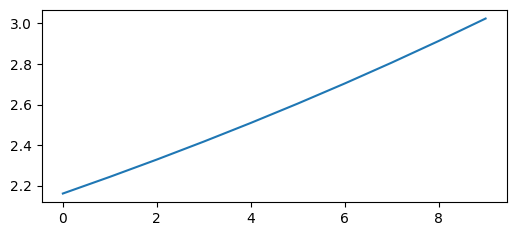

In [63]:
plt.figure(figsize=(6, 2.5))
plt.plot(lambda_mem)

In [ ]:
Ssorp = 2.5/22 * iload / F * (lambda_ccl - lambda_acl) / (np.exp(2e-5/Klambda) - 1)